# BattMo Workshop

The workshop consists of the following parts:
- **Hello BattMo**: a short introduction to BattMo.jl
- **P4D modelling**: explore how to simulate a 3D geometry in BattMo.jl
- **Thermal modelling**: explore the thermal model in BattMo.jl and use the by the dS-Toolbox computed entropy coefficient to improve our thermal results

##### Import packages

In [1]:
using BattMo, Plots, Unitful, Jutul, CSV, DataFrames, Statistics
include("./input_files/function_parameters_xu_2015.jl")

include("./scripts/plotting_functions.jl")

gr()

Plots.GRBackend()

## Hello BattMo

Welcome to this hands-on tutorial where we’ll explore the basics of BattMo.jl — a powerful Julia package for simulating lithium-ion battery cells using physics-based models like the Doyle-Fuller-Newman (DFN) model. 

By the end of this part of the tutorial, you’ll:

- Understand some basic features of BattMo.jl
- Run your first battery simulation
- Explore and visualize the output
- Learn how to tweak key parameters for custom behavior

#### Input format

BattMo.jl structures its simulation inputs into two primary categories: Parameters and Settings. This distinction helps users differentiate between the physical characteristics of the battery system and the numerical configurations of the simulation.

**Parameters** represent the controllable variables in real-world experiments. They are further divided into:

- **Cell Parameters**: define the intrinsic properties of the battery cell, such as geometry and material characteristics.
- **Cycling Protocol Parameters**: specify how the cell is operated during a simulation.

**Settings** are used to configure numerical assumptions for solving equations and finding numerical solutions. They are further divided into:

- **Model Settings**: define numerical assumptions related to the battery model, such as diffusion methods or simplifications used in the simulation.
- **Simulation Settings**: define numerical assumptions specific to the simulation process, including time-stepping schemes and discretization precision.
- **Solver Settings**: define solver behavior and verbosity.

**BattMo** stores cell parameters, cycling protocols and settings in a user-friendly JSON format to facilitate reuse.

#### Load and modify input files

In [2]:
include("./input_files/function_parameters_xu_2015.jl")

cell_parameters = load_cell_parameters(; from_file_path = "input_files/cell_parameters.json");
cycling_protocol = load_cycling_protocol(; from_file_path = "input_files/cc_discharge.json");

In [3]:
print_info(cell_parameters)


PARAMETER OVERVIEW
Parameter                                                                                 Unit                Type                Value                         
----------------------------------------------------------------------------------------------------------------------------------------------------------------
[ "Cell" ][ "Case" ]                                                                      N/A                 String              Pouch                         
[ "Cell" ][ "DoubleCoatedElectrodes" ]                                                    -                   Bool                false                         
[ "Cell" ][ "ElectrodeGeometricSurfaceArea" ]                                             m²                  Float64             0.00668                       
[ "Cell" ][ "ElectrodeLength" ]                                                           m                   Float64             0.105                         
[ "Cell" ][ "E

To change cell parameters, we can modify the JSON files directly, or we can read them into objects in the script and modify them as Dictionaries. A loaded cell parameter set is a Dictionary-like object which come with additional handy functions like the `print_info` we just used.

Parameters that take single numerical values (e.g. real, integers, booleans) can be directly modified.

In [4]:
cell_parameters["PositiveElectrode"]["Coating"]["Thickness"] = 92.0e-6

9.2e-5

Some parameters are described as functions or arrays, since the parameter value depends on other variables. For instance the Open Circuit Potentials of the Active Materials depend on the lithium stoichiometry. When we're unsure about the type or meaning of a parameter, we can print information on invidual parameters as well. For some parameters, that require more explanation, a link to the documentation is provided. Visit the documentation of the OpenCircuitPotential parameter to find more information on how to implement you own user defined functional parameters.

In [5]:
parameter_name = "OpenCircuitPotential"

print_info(parameter_name, view = "CellParameters")


----------------------------------------------------------------------------------------------------
🔋  Cell Parameter:  OpenCircuitPotential
----------------------------------------------------------------------------------------------------
    🔹 Name               OpenCircuitPotential
    🔹 Category           CellParameters
    🔹 Description        The open-circuit potential of the active material under a given intercalant stoichimetry and temperature.
    🔹 Type               String, Dict{String, Vector}, Real
    🔹 Unit               V
    🔹 Documentation      [visit](https://battmo.org/BattMo.jl/dev/manuals/user_guide/simulation_dependent_input)

    🔹 Ontology link      [visit](https://w3id.org/emmo/domain/electrochemistry#electrochemistry_9c657fdc_b9d3_4964_907c_f9a6e8c5f52b)




The cycling protocol parameters and the settings (model settings, simulation settings, solver settings) can be loaded, viewed and altered in the same way as the cell parameters. Let's load the CC discharge protocol that we have in our input files. The settings we'll go into later.

In [6]:
cycling_protocol = load_cycling_protocol(; from_file_path = "input_files/cc_discharge.json");
print_info(cycling_protocol)


PARAMETER OVERVIEW
Parameter                                                                                 Unit                Type                Value                         
----------------------------------------------------------------------------------------------------------------------------------------------------------------
[ "DRate" ]                                                                               1                   Float64             0.5                           
[ "InitialControl" ]                                                                      N/A                 String              discharging                   
[ "InitialStateOfCharge" ]                                                                1                   Float64             0.99                          
[ "LowerVoltageLimit" ]                                                                   V                   Float64             2.5                           
[ "Protocol" ]

#### Run a simulation

In this part we'll show how you can run a simple P2D simulation. Let's start by loading the Xu 2015 cell parameter set and a constant current discharge cycling protocol.

In [7]:
cell_parameters = load_cell_parameters(; from_file_path = "input_files/cell_parameters.json");
cycling_protocol = load_cycling_protocol(; from_file_path = "input_files/cc_discharge.json");

Next, we select the default Lithium-Ion Battery model. A model can be thought as a mathematical implementation of the electrochemical and transport phenomena occuring in a real battery cell. The implementation consist of a system of partial differential equations and their corresponding parameters, constants and boundary conditions. The default Lithium-Ion Battery setup selected below contains the model settings to simulate a basic P2D model, where neither current collectors nor SEI growth are considered.

In [8]:
model = LithiumIonBattery();

✔️ Validation of ModelSettings passed: No issues found.
──────────────────────────────────────────────────


The LithiumIonBattery constructor validates the model settings on the back ground. If the model setup is valid we can continue and create a Simulation object by passing the model setup, cell parameters and a cycling protocol.

In [9]:
sim = Simulation(model, cell_parameters, cycling_protocol);

✔️ Validation of CellParameters passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CyclingProtocol passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SimulationSettings passed: No issues found.
──────────────────────────────────────────────────


The simulation object is only instantiated when the model provided is valid. We can see that the Simulation object also validates the parameters and settings on the back ground. Each parameter set is validated on whether they are sensible and complete. 

When the Simulation object is valid we can solve the simulation by passing the object to the solve function. As Julia is a compiled language, the first time that we run a simulation it will take some time to compile the functions and structs that it encounters. This makes running a second simulation very fast. See the difference by running the script for a second time.

In [10]:
output = solve(sim);

✔️ Validation of SolverSettings passed: No issues found.
──────────────────────────────────────────────────
Jutul: Simulating 2 hours, 12 minutes as 163 report steps


Progress   1%|█                                          |  ETA: 0:23:43

Progress  62%|███████████████████████████                |  ETA: 0:00:11

Progress 100%|███████████████████████████████████████████| Time: 0:00:19


╭────────────────┬───────────┬───────────────┬──────────╮
│ Iteration type │  Avg/step │  Avg/ministep │    Total │
│                │ 138 steps │ 138 ministeps │ (wasted) │
├────────────────┼───────────┼───────────────┼──────────┤
│ Newton         │   2.15217 │       2.15217 │  297 (0) │
│ Linearization  │   3.15217 │       3.15217 │  435 (0) │
│ Linear solver  │   2.15217 │       2.15217 │  297 (0) │
│ Precond apply  │       0.0 │           0.0 │    0 (0) │
╰────────────────┴───────────┴───────────────┴──────────╯
╭───────────────┬─────────┬────────────┬─────────╮
│ Timing type   │    Each │   Relative │   Total │
│               │      ms │ Percentage │       s │
├───────────────┼─────────┼────────────┼─────────┤
│ Properties    │  1.1280 │     1.90 % │  0.3350 │
│ Equations     │ 22.1145 │    54.57 % │  9.6198 │
│ Assembly      │  4.6177 │    11.39 % │  2.0087 │
│ Linear solve  │  2.6203 │     4.41 % │  0.7782 │
│ Linear setup  │  0.0000 │     0.00 % │  0.0000 │
│ Precond apply │  

We can use some built in functions for quick plotting. The dashboard gives you a quick overview of some important ouput variables.

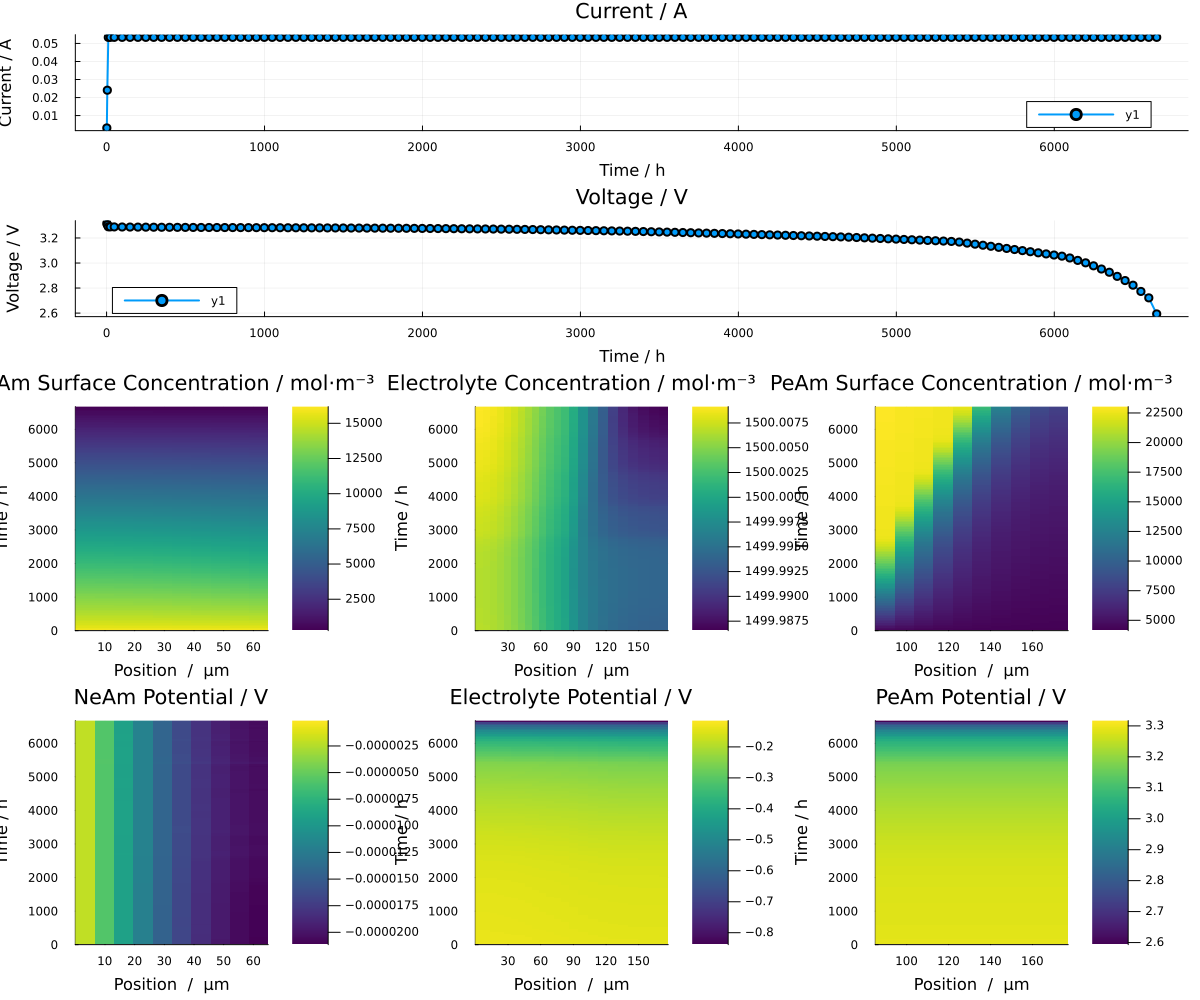

In [11]:
plot_dashboard(output; plot_type = "contour")

Within the surface concentration of the positive electrode we can see that only part of the electrode is utilized. Why could this be the case? We always recommend to use our `quick_cell_check` function to quickly get access to some common battery cell KPIs like the cell theoretical capacity, n:p ratio, cell mass, etc. to get a first idea of the parameter set and if any of the equilibrium state quantities seem correct and realistic.

In [12]:
quick_cell_check(cell_parameters)

════════════════════════════════════════════════════════════════════════════════════════════════════════════
🔋 Quick Cell Check
════════════════════════════════════════════════════════════════════════════════════════════════════════════
Cell 1: Xu2015

Quantity                                Cell 1         | Unit         | Source
────────────────────────────────────────────────────────────────────────────────────────────────────────────
Nominal Voltage                         3.2            | V            | [INPUT]     
Nominal Capacity                        N/A            | Ah           | [INPUT]     
Cell Theoretical Capacity               0.1067         | Ah           | [EQUILIBRIUM CALCULATION]
Cell N:P Ratio                          0.6101         | -            | [EQUILIBRIUM CALCULATION]
Cell Mass                               0.00236        | kg           | [EQUILIBRIUM CALCULATION]
Positive Electrode Mass Loading         15.0           | mg/cm²       | [EQUILIBRIUM CALCULATIO

From the quick cell check we can see that the n:p ratio of the cell is way below 1.0. As we probably now, in order to prevent lithium plating and the reducing the chance of internal short circuit, the n:p ratio should always be higher than 1.0.

## -Assignment

Adjust the negative electrode coating thickness to improve the electrode balancing (n:p ratio) so that we can run the following simulations during this tutorial with a realistic cell input parameter set. You can use `quick_cell_check` to see if your n:p ratio is improved

Run a simulation with the improved cell parameters and plot the dashboard to see if the change in thickness has influence on the lithium surface concentration of the positive electrode.

#### Handle Output

In BattMo.jl the output variables are divided into three different categories:
- **time series**: all variables that depent on time.
- **states**: all the state variables, which can be dependent on time, axial position and radial position.
- **metrics**: the calculated cell metrics, dependent on the cycle index.

In order to investigate how to retrieve output quantities, let's simulate a couple of constant current constant voltage cycles.

In [15]:
cycling_protocol = load_cycling_protocol(; from_file_path = "input_files/cccv.json");
print_info(cycling_protocol)


PARAMETER OVERVIEW
Parameter                                                                                 Unit                Type                Value                         
----------------------------------------------------------------------------------------------------------------------------------------------------------------
[ "CRate" ]                                                                               1                   Float64             1.0                           
[ "CurrentChangeLimit" ]                                                                  A·s⁻¹               Float64             0.0001                        
[ "DRate" ]                                                                               1                   Float64             1.0                           
[ "InitialControl" ]                                                                      N/A                 String              charging                      
[ "InitialStat

✔️ Validation of ModelSettings passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CellParameters passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CyclingProtocol passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SimulationSettings passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SolverSettings passed: No issues found.
──────────────────────────────────────────────────
Jutul: Simulating 2 days, 2 hours as 3600 report steps


Progress   0%|█                                          |  ETA: 2:52:25

Progress   0%|█                                          |  ETA: 2:01:31

Progress   1%|█                                          |  ETA: 0:19:27

Progress   1%|█                                          |  ETA: 0:09:23

Progress   2%|█                                          |  ETA: 0:06:20

Progress   2%|█                                          |  ETA: 0:04:48

Progress   3%|██                                         |  ETA: 0:04:00

Progress   3%|██                                         |  ETA: 0:03:25

Progress   4%|██                                         |  ETA: 0:03:03

Progress   4%|██                                         |  ETA: 0:02:43

Progress   5%|██                                         |  ETA: 0:02:27

Progress   5%|███                                        |  ETA: 0:02:18

Progress   5%|███                                        |  ETA: 0:02:08

Progress   6%|███                     

╭────────────────┬────────────┬────────────────┬──────────────╮
│ Iteration type │   Avg/step │   Avg/ministep │        Total │
│                │ 2840 steps │ 3187 ministeps │     (wasted) │
├────────────────┼────────────┼────────────────┼──────────────┤
│ Newton         │    4.24296 │        3.78099 │ 12050 (4960) │
│ Linearization  │    5.36514 │        4.78099 │ 15237 (5208) │
│ Linear solver  │    4.24296 │        3.78099 │ 12050 (4960) │
│ Precond apply  │        0.0 │            0.0 │        0 (0) │
╰────────────────┴────────────┴────────────────┴──────────────╯
╭───────────────┬────────┬────────────┬─────────╮
│ Timing type   │   Each │   Relative │   Total │
│               │     ms │ Percentage │       s │
├───────────────┼────────┼────────────┼─────────┤
│ Properties    │ 1.1757 │    28.11 % │ 14.1674 │
│ Equations     │ 0.6648 │    20.10 % │ 10.1301 │
│ Assembly      │ 0.2495 │     7.54 % │  3.8012 │
│ Linear solve  │ 0.9108 │    21.77 % │ 10.9748 │
│ Linear setup  │ 0.0000

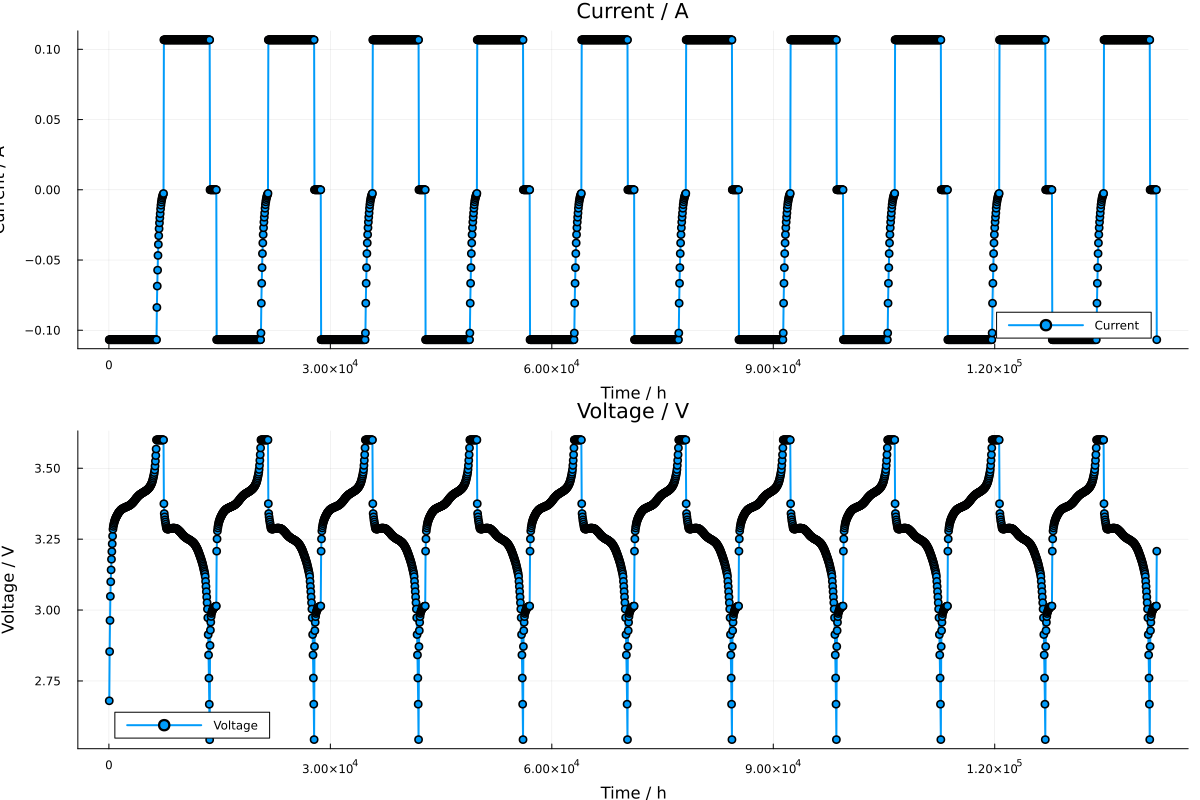

In [16]:

cycling_protocol["TotalNumberOfCycles"] = 10

model_setup = LithiumIonBattery()

sim = Simulation(model_setup, cell_parameters, cycling_protocol);

output = solve(sim);

plot_dashboard(output, plot_type = "simple")

Let's use the output from the previous CCCV simulation. We can again use the print info function to have a look into which output variables are available.

In [17]:
print_info(output)


OUTPUT OVERVIEW
Variable                                                                                                 Unit                Shape                         
-----------------------------------------------------------------------------------------------------------------------------------------------------------

TIME_SERIES
Variable                                                                                                 Unit                Shape                         
-----------------------------------------------------------------------------------------------------------------------------------------------------------
[ "CumulativeCapacity" ]                                                                                 Ah                  (nTime,)                      
[ "Current" ]                                                                                            A                   (nTime,)                      
[ "CycleNumber" ]                 

In the overview we can quickly see the aivalable variables and their units. We can also see that the variables have been devided into three categories like explained above: time series, states, and metrics. This has been done to provide some structure to the variables that is intuitive and cleans up the data. We also use these three categories when retrieving data. Let's first retrieve for example time series data like voltage, current and time.

In [18]:
time_series = output.time_series

t = time_series["Time"]
E = time_series["Voltage"]
I = time_series["Current"];

Let's now retrieve some state variables

In [19]:
states = output.states

electrolyte_concentration = states["Electrolyte"]["Concentration"]
electrolyte_potential = states["Electrolyte"]["Potential"];

We can also print more information on each individual variable. For example, to look into the difference between the electrode particle concentration and surface concentration.

In [20]:
print_info("NegativeElectrodeActiveMaterialParticleConcentration")


----------------------------------------------------------------------------------------------------
📈  Output Variable:  NegativeElectrodeActiveMaterialParticleConcentration
----------------------------------------------------------------------------------------------------
    🔹 Name               NegativeElectrodeActiveMaterialParticleConcentration
    🔹 Category           OutputVariable
    🔹 Description        Radial distribution of lithium concentration in negative electrode particles.
    🔹 Type               Vector{Real}
    🔹 Shape              (nTime, nPosition, nRadius)
    🔹 Unit               mol·L⁻¹



We can have a better idea of what the variable represents by reading the description and checking the shape of the variable. We can also retrieve some metrics from the output.

In [21]:
metrics = output.metrics

discharge_capacity = metrics["DischargeCapacity"]
round_trip_efficiency = metrics["RoundTripEfficiency"]
cycle_index = metrics["CycleIndex"];

Let's plot the discharge capacity and round trip efficiency against its cycle index.

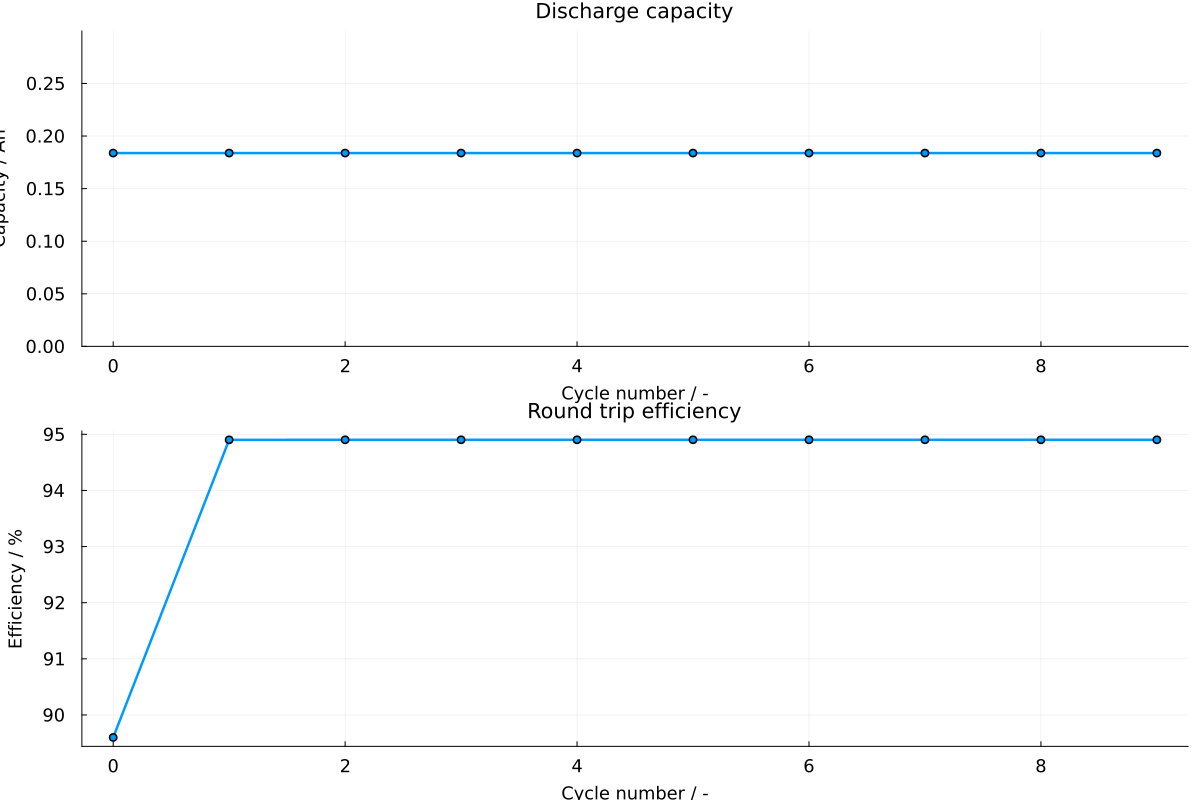

In [22]:
lw = 2.5
fs = 12

p1 = plot(
    cycle_index, discharge_capacity,
    linewidth = lw,
    ylabel = "Capacity / Ah",
    xlabel = "Cycle number / -",
    title = "Discharge capacity",
    marker = :circle,
    markersize = 4,
    grid = true,
    legend = false,
    ylims = (0.0, 0.3)
)

p2 = plot(
    cycle_index, round_trip_efficiency,
    linewidth = lw,
    ylabel = "Efficiency / %",
    xlabel = "Cycle number / -",
    title = "Round trip efficiency",
    marker = :circle,
    markersize = 4,
    grid = true,
    legend = false
)

plot(
    p1, p2,
    layout = (2,1),
    size = (1200,800),
    tickfontsize = fs,
    guidefontsize = fs,
    titlefontsize = fs + 2
)

## P4D modelling

In order to get an accurate representation of the thermal effects within a cell we need to run the simulation on a 3D geometry instead of a 1D. So, let's have a look into how can simulate the 3D pouch geometry described in our cell parameters.

What kind of models did we use during the previous simulation? The submodels that are used during a simulation are specified within the model object. Let's have a look what the model that we instantiated earlier contains.

In [23]:
model.settings

{
    "ButlerVolmer" => "Standard"
    "RampUp" => "Sinusoidal"
    "Metadata" =>     {
        "Description" => "Default model settings for a P2D simulation including a current ramp up, excluding current collectors and SEI effects."
        "Title" => "p2d"
    }
    "PotentialFlowDiscretization" => "GeneralAD"
    "TransportInSolid" => "FullDiffusion"
    "ModelFramework" => "P2D"
}

We can see that it contains a couple of submodel settings. We can see that we ran a P2D simulation, and that's it, not more special than that. From the following print function we can see which submodels are availabe to specify within the model settings.

In [24]:
print_submodels()

ℹ️  Submodels Information
Parameter                     Options                                           Documentation
----------------------------------------------------------------------------------------------------
ButlerVolmer                  Standard, Chayambuka                              [visit](https://battmoteam.github.io/BattMo.jl/dev/manuals/user_guide/pxd_model)

CurrentCollectors             Standard                                          -         
SEIModel                      Bolay                                             [visit](https://battmoteam.github.io/BattMo.jl/dev/manuals/user_guide/sei_model)

RampUp                        Sinusoidal                                        [visit](https://battmoteam.github.io/BattMo.jl/dev/manuals/user_guide/ramp_up)

TemperatureDependence         Arrhenius                                         [visit](https://battmoteam.github.io/BattMo.jl/dev/manuals/user_guide/arrhenius)

PotentialFlowDiscretization   GeneralAD, T

For the following simulations we would like to use the P4D Pouch framework. We can specify this by altering the model. We would also like to model the current collectors in the 3D geometry, so we add those to the settings as well.

In [25]:
model.settings["ModelFramework"] = "P4D Pouch"
model.settings["CurrentCollectors"] = "Standard";

Instead of modifying the model instance directly, for clearity and repeatability, it's better to setup your own model_settings input file and pass that to the battery model of choice.

In [26]:
model_settings = load_model_settings(; from_file_path = "input_files/model_settings.json")

model_settings["ModelFramework"] = "P4D Pouch"
model_settings["CurrentCollectors"] = "Standard"

model = LithiumIonBattery(;model_settings);

✔️ Validation of ModelSettings passed: No issues found.
──────────────────────────────────────────────────


Let's setup the simulation for a simple CC discharge and visualize our geometry.

In [27]:
cycling_protocol = load_cycling_protocol(; from_file_path = "input_files/cc_discharge.json");

sim_3d = Simulation(model, cell_parameters, cycling_protocol);

✔️ Validation of CellParameters passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CyclingProtocol passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SimulationSettings passed: No issues found.
──────────────────────────────────────────────────


Within BattMo.jl, we have super handy interactive plotting functions where you can view your geometry and play around with results and components. Here a figure of what this looks like:

![3d_plot.png](public/3d_plot.png)

Unfortunetaly, in the Jupyter hub, we're not able to run these interactive plots, so we'll have to do with static plotting... Let's plot our geometry grid.

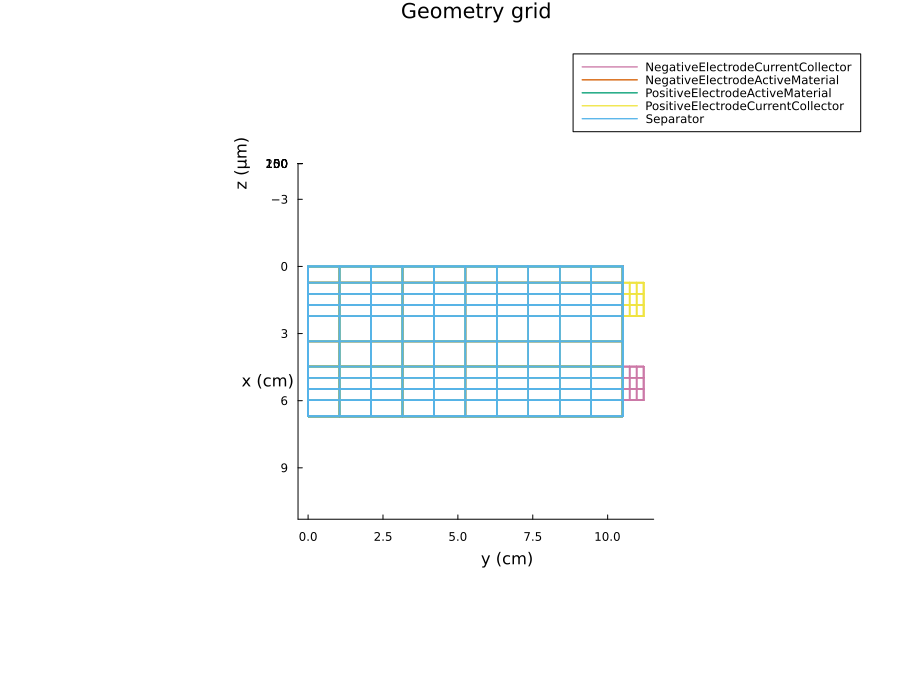

In [28]:
grids = sim_3d.grids

plot_grid(grids; include = [
    "NegativeElectrodeActiveMaterial", 
    "NegativeElectrodeCurrentCollector", 
    "Separator",
    "PositiveElectrodeActiveMaterial",
    "PositiveElectrodeCurrentCollector"
    ],
    camera=(90, 90)
    )

## - Assignment

Let's design our own Pouch geometry! Have a look at the parameter specifications in the documentation to see what parameters you can change: https://battmo.org/BattMo.jl/dev/manuals/user_guide/geometries.

Adjust the cell_parameters object and initiate the Simulation object with the adapted cell parameters to setup the grid for your own geometry design.

Plot your geometry using the `plot_grid` function.

Let's run the simulation for this 3d geometry.

In [31]:
output_3d = solve(sim_3d);

✔️ Validation of SolverSettings passed: No issues found.
──────────────────────────────────────────────────
Jutul: Simulating 2 hours, 12 minutes as 163 report steps


Progress   1%|█                                          |  ETA: 0:50:34

Progress   2%|█                                          |  ETA: 0:34:36

Progress   2%|██                                         |  ETA: 0:26:57

Progress   3%|██                                         |  ETA: 0:21:56

Progress   4%|██                                         |  ETA: 0:18:31

Progress   4%|██                                         |  ETA: 0:16:06

Progress   5%|███                                        |  ETA: 0:14:14

Progress   5%|███                                        |  ETA: 0:12:47

Progress   6%|███                                        |  ETA: 0:11:39

Progress   7%|███                                        |  ETA: 0:10:42

Progress   7%|████                                       |  ETA: 0:09:54

Progress   8%|████                                       |  ETA: 0:09:13

Progress   9%|████                                       |  ETA: 0:08:38

Progress   9%|████                    

╭────────────────┬───────────┬───────────────┬──────────╮
│ Iteration type │  Avg/step │  Avg/ministep │    Total │
│                │ 138 steps │ 138 ministeps │ (wasted) │
├────────────────┼───────────┼───────────────┼──────────┤
│ Newton         │   2.11594 │       2.11594 │  292 (0) │
│ Linearization  │   3.11594 │       3.11594 │  430 (0) │
│ Linear solver  │   2.11594 │       2.11594 │  292 (0) │
│ Precond apply  │       0.0 │           0.0 │    0 (0) │
╰────────────────┴───────────┴───────────────┴──────────╯
╭───────────────┬──────────┬────────────┬──────────╮
│ Timing type   │     Each │   Relative │    Total │
│               │       ms │ Percentage │        s │
├───────────────┼──────────┼────────────┼──────────┤
│ Properties    │  16.7871 │     3.41 % │   4.9018 │
│ Equations     │  96.5555 │    28.92 % │  41.5189 │
│ Assembly      │   8.1236 │     2.43 % │   3.4932 │
│ Linear solve  │ 276.4751 │    56.24 % │  80.7307 │
│ Linear setup  │   0.0000 │     0.00 % │   0.0000 │
│

We can interactively visualize the states on our 3D geometry using our internal plotting tools, but as said before, they won't work on the hub. So for this tutorial, we'll stick to more simple 2D plotting. Let's plot the surface concentration of lithium in the positive electrode.

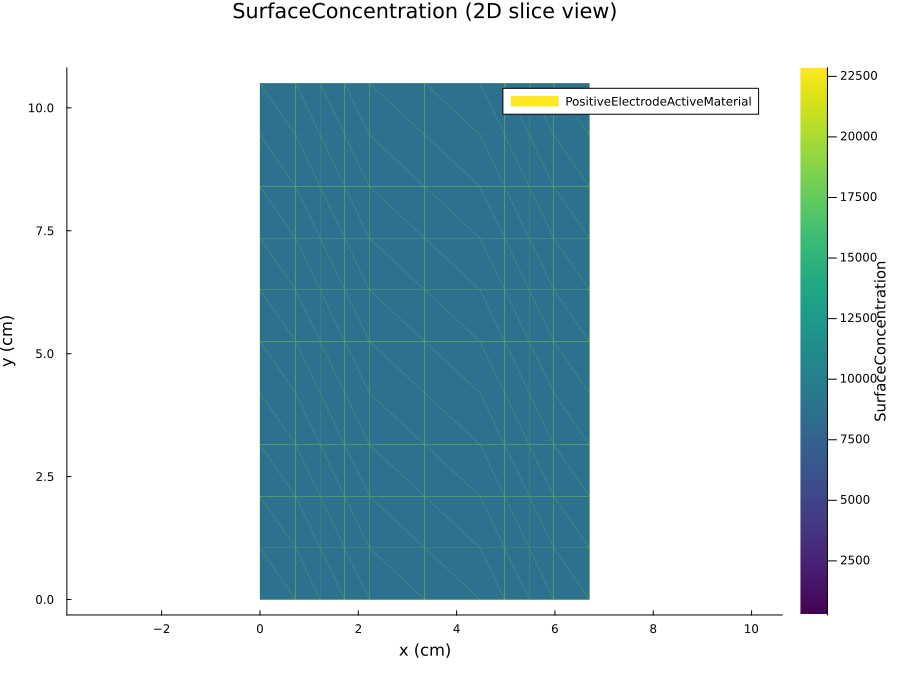

In [32]:
time = output_3d.time_series["Time"]
n = length(time)
plot_cell_data_2d(grids, output_3d;
    variable = "SurfaceConcentration",
    include = [
        "PositiveElectrodeActiveMaterial",
    ],
    timestep = n)

## Thermal Modelling

Now, we are finaly ready to look into thermal modelling. BattMo.jl has two types of thermal models implemented at the moment: decoupled and sequential. Within the decoupled one, the thermal model is simulated only after the electrochemical simulation is fully finished, while the sequential model updates the thermal simulation at every time step after the electrochemical state has been computed. For this workshop we'll use the sequential model as it is the more accurate model of the two.

In [33]:
model.settings["ThermalModel"] = "Sequential";

For the thermal model, we can make some of the input parameters dependent on temperature. For this tutorial we'll focus on the entropy change. Let's shortly dive into some theory on the role of the entropy change in the thermal model.

#### Role in Open circuit potential
In physics-based lithium-ion battery models, the **entropy change parameter** $\frac{\partial U}{\partial T}$ describes how the open-circuit potential (OCP) varies with temperature. The open-circuit potential is generally expressed as a function of stoichiometry and temperature:

$$
U = U(\theta, T) = OCP(\theta)_{ref} + \frac{\partial U}{\partial T} (T - T_{ref})
$$

where:

- $U$ is the open-circuit potential (OCP),
- $\theta$ is the electrode stoichiometry or state of lithiation,
- $T$ is temperature.
- $OCP_{ref}$ is the OCP measured at the reference temperature (25 $\deg$ C)

#### Role in Reversible Heat Generation

The entropy change is directly related to the electrochemical entropy of the cell reaction. In battery thermal models, the total heat generation is commonly decomposed into:

1. **Irreversible (ohmic + reaction) heat**
2. **Reversible (entropic) heat**

The reversible heat source term is given by:

$$
\dot{Q}_{rev} = I T \frac{\partial U}{\partial T}
$$

where:

- $\dot{Q}_{rev}$ is the reversible heat generation rate,
- $I$ is the applied current,
- $T$ is cell temperature,
- $\frac{\partial U}{\partial T}$ is the entropy coefficient.

This term can either produce heat or absorb heat depending on the sign of both current and entropy change. As a result, reversible heating is especially important during low-rate operation where irreversible losses are relatively small.

Including the entropy change parameter improves the accuracy of thermal effects in the battery cell. In this part of the tutorial we'll have a look into the difference in results between a thermal simulation that doesn't include the entropy change, and a simulation that does include the entrop change (computed by the dS-Toolbox).

Lets first do a simulation without the entropy change. The thermal model expects the entropy change parameter to be specified, therefore, we need to specify it as zero in our case. Let's print some information on the entropy change parameter so we now how to specify it.

In [34]:
print_info("Entropy")


----------------------------------------------------------------------------------------------------
🔋  Cell Parameter:  EntropyChange
----------------------------------------------------------------------------------------------------
    🔹 Name               EntropyChange
    🔹 Category           CellParameters
    🔹 Description        The entropy change of the active material derived from the open-circuit potential, representing the temperature dependence of the electrochemical potential (dU/dT).
    🔹 Type               String, Dict{String, Vector}, Real
    🔹 Unit               V/K
    🔹 Documentation      [visit](https://battmo.org/BattMo.jl/dev/manuals/user_guide/simulation_dependent_input)

    🔹 Ontology link      [visit](https://w3id.org/emmo/domain/electrochemistry#electrochemistry_entropy_change)




We can see that it's a simulation dependent parameter, it namely depends on the lithium stoichiometry and therefore can be provided to the input parameters as a string, dict, or real value. We can for example setup a function that computes the entropy and pass the name of the function as input parameter value, so that the simulation will use that function to calculate the value. 

In [35]:
function entropy_change_function_zero(c, cmax)
    return 0.0
end


const entropy_change_function_zero = entropy_change_function_zero


entropy_change_function_zero (generic function with 1 method)

Let's run the simulation without the entropy change.

In [36]:
cell_parameters_no_entropy = deepcopy(cell_parameters)

cell_parameters_no_entropy["PositiveElectrode"]["ActiveMaterial"]["EntropyChange"] = Dict(
    "FunctionName" => "entropy_change_function_zero",
)

cell_parameters_no_entropy["NegativeElectrode"]["ActiveMaterial"]["EntropyChange"] = Dict(
    "FunctionName" => "entropy_change_function_zero",
)

cycling_protocol = load_cycling_protocol(; from_file_path = "input_files/cc_discharge.json")

cycling_protocol["InitialTemperature"] = 25 + 273.15
cycling_protocol["AmbientTemperature"] = 30 + 273.15

cycling_protocol["DRate"] = 0.5
sim_thermal_no_entropy = Simulation(model, cell_parameters_no_entropy, cycling_protocol);

output_thermal_no_entropy = solve(sim_thermal_no_entropy);

✔️ Validation of CellParameters passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CyclingProtocol passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SimulationSettings passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SolverSettings passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CellParameters passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CyclingProtocol passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SimulationSettings passed: No issues found.
──────────────────────────────────────────────────
Jutul: Simulating 2 hours, 12 minutes as 163 report steps


Progress   1%|█                                          |  ETA: 1:31:27

Progress   2%|█                                          |  ETA: 1:01:47

Progress   2%|██                                         |  ETA: 0:47:18

Progress   3%|██                                         |  ETA: 0:37:58

Progress   4%|██                                         |  ETA: 0:31:47

Progress   4%|██                                         |  ETA: 0:27:19

Progress   5%|███                                        |  ETA: 0:24:06

Progress   5%|███                                        |  ETA: 0:21:32

Progress   6%|███                                        |  ETA: 0:19:28

Progress   7%|███                                        |  ETA: 0:17:46

Progress   7%|████                                       |  ETA: 0:16:22

Progress   8%|████                                       |  ETA: 0:15:10

Progress   9%|████                                       |  ETA: 0:14:08

Progress   9%|████                    

╭────────────────┬───────────┬───────────────┬──────────╮
│ Iteration type │  Avg/step │  Avg/ministep │    Total │
│                │ 138 steps │ 138 ministeps │ (wasted) │
├────────────────┼───────────┼───────────────┼──────────┤
│ Newton         │   2.11594 │       2.11594 │  292 (0) │
│ Linearization  │   3.11594 │       3.11594 │  430 (0) │
│ Linear solver  │   2.11594 │       2.11594 │  292 (0) │
│ Precond apply  │       0.0 │           0.0 │    0 (0) │
╰────────────────┴───────────┴───────────────┴──────────╯
╭───────────────┬──────────┬────────────┬──────────╮
│ Timing type   │     Each │   Relative │    Total │
│               │       ms │ Percentage │        s │
├───────────────┼──────────┼────────────┼──────────┤
│ Properties    │  18.1342 │     2.87 % │   5.2952 │
│ Equations     │ 106.9254 │    24.93 % │  45.9779 │
│ Assembly      │  10.8768 │     2.54 % │   4.6770 │
│ Linear solve  │ 278.6437 │    44.11 % │  81.3640 │
│ Linear setup  │   0.0000 │     0.00 % │   0.0000 │
│

Now, let's do the simulation including the entropy change that was calculated by the dS-Toolbox. We can add the entropy coefficient calculated by the dS-Toolbox in a similar way.

Let's load the entropy coefficient data from the dS-Toolbox

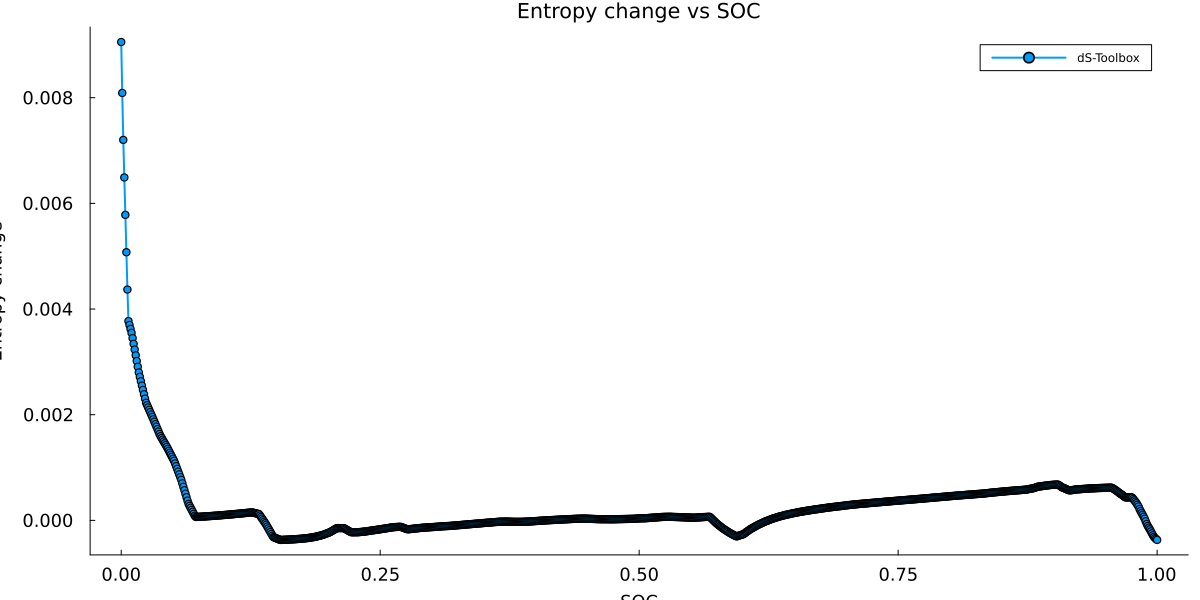

In [37]:
# 1. Read data
root_path = dirname(pwd())

path = joinpath(
    root_path,
    "dS-Toolbox",
    "Entropy_data",
    "BattMo_dUdT.csv"
)
df = CSV.read(path, DataFrame)

soc = df[:, 1]
entropy_change = df[:, 2];

p = plot(
    soc,
    entropy_change,
    label = "dS-Toolbox",
    linewidth = 2,
    marker = :circle,
    markersize = 4,
    title = "Entropy change vs SOC",
    xlabel = "SOC",
    ylabel = "Entropy change",
    legend = true,
    grid = false
)

plot(
    p,
    size = (1200, 600),
    tickfontsize = fs,
    guidefontsize = fs,
    titlefontsize = fs + 2
)

We can interpolate the data and return the interpolation within a function.

In [38]:
# 2. Use a Jutul interpolator to create an interpolation object of the time and power data
entropy_intp = Jutul.get_1d_interpolator(soc, entropy_change, cap_endpoints = true)


# 3. Define a function to calculate the entropy change.

function entropy_change_function(c, cmax)
    cm = float(cmax)
    cv = float(c)

    soc = cv / cm

    soc = clamp(soc, 0.0, 1.0)

    return entropy_intp(soc)
end


const entropy_change_function = entropy_change_function


entropy_change_function (generic function with 1 method)

Now we have to let BattMo.jl now that we want it to compute the entropy change using this function. To do this we add the name of the function to the cell parameters input file.

In [39]:
cell_parameters_entropy = deepcopy(cell_parameters)

cell_parameters_entropy["PositiveElectrode"]["ActiveMaterial"]["EntropyChange"] = Dict(
    "FunctionName" => "entropy_change_function",
)

cell_parameters_entropy["NegativeElectrode"]["ActiveMaterial"]["EntropyChange"] = Dict(
    "FunctionName" => "entropy_change_function",
)

Dict{String, String} with 1 entry:
  "FunctionName" => "entropy_change_function"

In [40]:
cycling_protocol = load_cycling_protocol(; from_file_path = "input_files/cc_discharge.json")

cycling_protocol["InitialTemperature"] = 25 + 273.15
cycling_protocol["AmbientTemperature"] = 30 + 273.15

303.15

In [41]:
sim_thermal = Simulation(model, cell_parameters_entropy, cycling_protocol);

✔️ Validation of CellParameters passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CyclingProtocol passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SimulationSettings passed: No issues found.
──────────────────────────────────────────────────


Now we can run the thermal simulation with entropy change

In [42]:

output_thermal = solve(sim_thermal);

✔️ Validation of SolverSettings passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CellParameters passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CyclingProtocol passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SimulationSettings passed: No issues found.
──────────────────────────────────────────────────
Jutul: Simulating 2 hours, 12 minutes as 163 report steps


Progress   1%|█                                          |  ETA: 0:27:46

Progress   2%|█                                          |  ETA: 0:19:11

Progress   2%|██                                         |  ETA: 0:15:08

Progress   3%|██                                         |  ETA: 0:12:22

Progress   4%|██                                         |  ETA: 0:10:31

Progress   4%|██                                         |  ETA: 0:09:10

Progress   5%|███                                        |  ETA: 0:08:17

Progress   5%|███                                        |  ETA: 0:07:35

Progress   6%|███                                        |  ETA: 0:06:59

Progress   7%|███                                        |  ETA: 0:06:32

Progress   7%|████                                       |  ETA: 0:06:05

Progress   8%|████                                       |  ETA: 0:05:45

Progress   9%|████                                       |  ETA: 0:05:23

Progress   9%|████                    

╭────────────────┬───────────┬───────────────┬──────────╮
│ Iteration type │  Avg/step │  Avg/ministep │    Total │
│                │ 138 steps │ 138 ministeps │ (wasted) │
├────────────────┼───────────┼───────────────┼──────────┤
│ Newton         │   2.41304 │       2.41304 │  333 (0) │
│ Linearization  │   3.41304 │       3.41304 │  471 (0) │
│ Linear solver  │   2.41304 │       2.41304 │  333 (0) │
│ Precond apply  │       0.0 │           0.0 │    0 (0) │
╰────────────────┴───────────┴───────────────┴──────────╯
╭───────────────┬──────────┬────────────┬──────────╮
│ Timing type   │     Each │   Relative │    Total │
│               │       ms │ Percentage │        s │
├───────────────┼──────────┼────────────┼──────────┤
│ Properties    │  13.8157 │     3.91 % │   4.6006 │
│ Equations     │  62.7237 │    25.10 % │  29.5429 │
│ Assembly      │   6.8876 │     2.76 % │   3.2440 │
│ Linear solve  │ 203.4959 │    57.58 % │  67.7641 │
│ Linear setup  │   0.0000 │     0.00 % │   0.0000 │
│

Let's compare the voltage curve with and withouth entropy change

In [43]:
t1 = output_thermal_no_entropy.time_series["Time"] ./ 3600
v1 = output_thermal_no_entropy.time_series["Voltage"]

t2 = output_thermal.time_series["Time"] ./ 3600
v2 = output_thermal.time_series["Voltage"]

voltage_difference = abs.(v2.-v1);

Compare the voltage curves

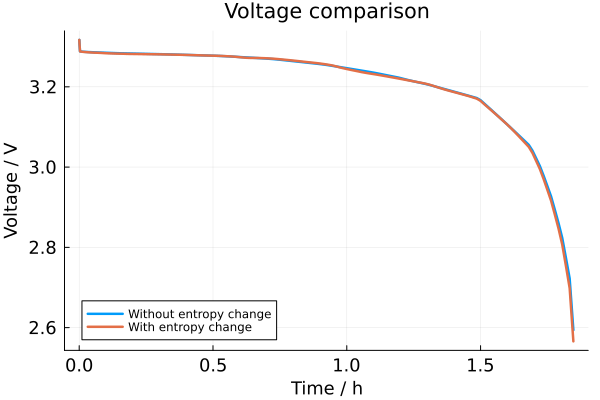

In [44]:


p = plot(
    t1,
    v1,
    linewidth = lw,
    xlabel = "Time / h",
    ylabel = "Voltage / V",
    title = "Voltage comparison",
    # marker = :circle,
    # markersize = 4,
    grid = true,
    legend = :bottomleft,
    label = "Without entropy change"
)

plot!(
    p,
    t2,
    v2,
    linewidth = lw,
    # marker = :circle,
    # markersize = 4,
    label = "With entropy change"
)

plot!(
    p,
    tickfontsize = fs,
    guidefontsize = fs,
    titlefontsize = fs + 2
)

display(p)

Plot the difference of the voltage curves

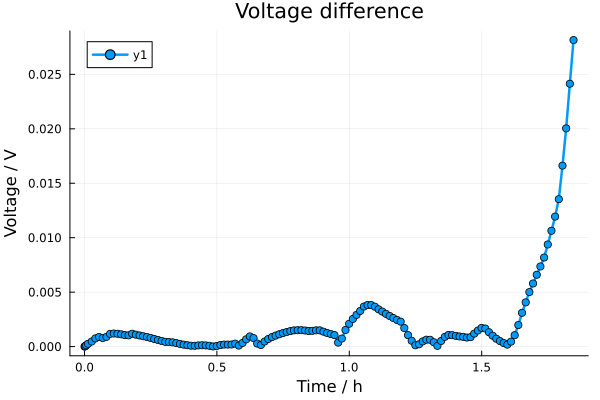

In [45]:
p = plot(
    t1,
    voltage_difference,
    linewidth = lw,
    xlabel = "Time / h",
    ylabel = "Voltage / V",
    title = "Voltage difference",
    marker = :circle,
    markersize = 4,
    grid = true,
)

Let's also make some plots to visualize the temperature results of the complete thermal model

In [46]:
print_info(output_thermal)


OUTPUT OVERVIEW
Variable                                                                                                 Unit                Shape                         
-----------------------------------------------------------------------------------------------------------------------------------------------------------

TIME_SERIES
Variable                                                                                                 Unit                Shape                         
-----------------------------------------------------------------------------------------------------------------------------------------------------------
[ "CumulativeCapacity" ]                                                                                 Ah                  (nTime,)                      
[ "Current" ]                                                                                            A                   (nTime,)                      
[ "CycleNumber" ]                 

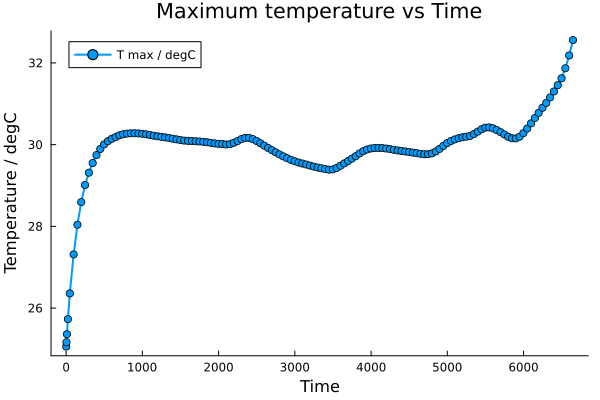

In [47]:
states = output_thermal.states
time_series = output_thermal.time_series

time = time_series["Time"]
T_max_ne = vec(maximum(states["NegativeElectrode"]["ActiveMaterial"]["Temperature"], dims = 2))
T_max_pe = vec(maximum(states["PositiveElectrode"]["ActiveMaterial"]["Temperature"], dims = 2))

p = Plots.plot(time, T_max_ne .- 273.15,
    label="T max / degC",
    linewidth=2,
   marker=:circle,
    markersize=4,
    title="Maximum temperature vs Time",
    xlabel="Time",
    ylabel="Temperature / degC",
    legend=true,
    grid=false  # optional, often faster without grid in Jupyter
)

Plots.display(p)

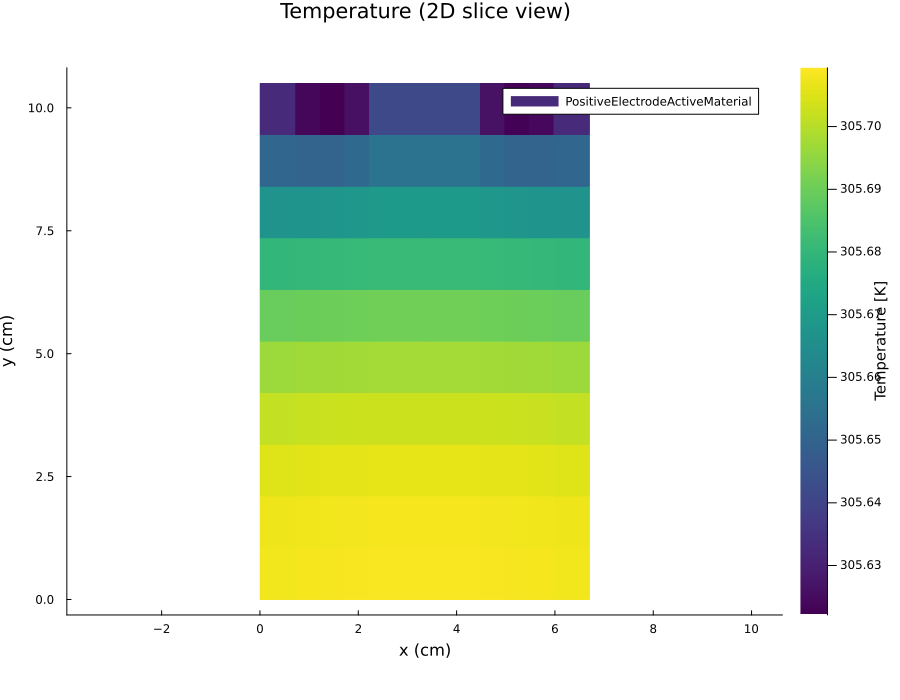

In [48]:

n = length(time)
plot_cell_data_2d(grids, output_thermal;
    variable = "Temperature",
    unit = "K",
    include = [
        "PositiveElectrodeActiveMaterial",
    ],
    timestep = n
)

## - Assignment

Let's investigate how hot we can make the battery cell until BattMo.jl's solvers can't keep up anymore. Adjust the initial and ambient temperature and solve the simulation to explore.

Plot the maximum temperature of the positive electrode over time like we did before.

In [ ]:
# Define discharge rates to simulate
drates = [0.2, 0.5, 1.0, 2.0]

# Plot settings
lw = 2

# Initialize plot
p = plot(
    xlabel = "Time / h",
    ylabel = "|ΔV| / V",
    title = "Voltage Difference Between Thermal Models",
    linewidth = lw,
    grid = true,
)

for drate in drates

    # Load protocol
    cycling_protocol = load_cycling_protocol(
        from_file_path = "input_files/cc_discharge.json"
    )

    cycling_protocol["InitialTemperature"] = 25 + 273.15
    cycling_protocol["AmbientTemperature"] = 30 + 273.15
    cycling_protocol["DRate"] = drate

    # -----------------------------
    # Thermal simulation WITHOUT entropy term
    # -----------------------------
    sim_thermal_no_entropy = Simulation(
        model,
        cell_parameters_no_entropy,
        cycling_protocol,
    )

    output_thermal_no_entropy = solve(sim_thermal_no_entropy)

    # -----------------------------
    # Thermal simulation WITH entropy term
    # -----------------------------
    sim_thermal = Simulation(
        model,
        cell_parameters_entropy,
        cycling_protocol,
    )

    output_thermal = solve(sim_thermal)

    # Extract time and voltage
    t = output_thermal.time_series["Time"] ./ 3600

    v_no_entropy = output_thermal_no_entropy.time_series["Voltage"]
    v_entropy = output_thermal.time_series["Voltage"]

    # Compute absolute voltage difference
    voltage_difference = abs.(v_entropy .- v_no_entropy)

    # Add curve to plot
    plot!(
        p,
        t[1:end-1],
        voltage_difference,
        label = "$(drate)C",
        linewidth = lw,
    )
end

display(p)

✔️ Validation of CellParameters passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CyclingProtocol passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SimulationSettings passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SolverSettings passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CellParameters passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CyclingProtocol passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SimulationSettings passed: No issues found.
──────────────────────────────────────────────────
Jutul: Simulating 5 hours, 30 minutes as 401 report steps


Progress   0%|█                                          |  ETA: 0:21:47

Progress   1%|█                                          |  ETA: 0:16:03

Progress   1%|█                                          |  ETA: 0:13:44

Progress   1%|█                                          |  ETA: 0:11:42

Progress   1%|█                                          |  ETA: 0:10:22

Progress   2%|█                                          |  ETA: 0:09:18

Progress   2%|█                                          |  ETA: 0:08:28

Progress   2%|█                                          |  ETA: 0:07:52

Progress   2%|██                                         |  ETA: 0:07:26

Progress   3%|██                                         |  ETA: 0:07:03

Progress   3%|██                                         |  ETA: 0:06:47

Progress   3%|██                                         |  ETA: 0:06:33

Progress   3%|██                                         |  ETA: 0:06:14

Progress   4%|██                      

╭────────────────┬───────────┬───────────────┬──────────╮
│ Iteration type │  Avg/step │  Avg/ministep │    Total │
│                │ 350 steps │ 350 ministeps │ (wasted) │
├────────────────┼───────────┼───────────────┼──────────┤
│ Newton         │   1.33714 │       1.33714 │  468 (0) │
│ Linearization  │   2.33714 │       2.33714 │  818 (0) │
│ Linear solver  │   1.33714 │       1.33714 │  468 (0) │
│ Precond apply  │       0.0 │           0.0 │    0 (0) │
╰────────────────┴───────────┴───────────────┴──────────╯
╭───────────────┬──────────┬────────────┬──────────╮
│ Timing type   │     Each │   Relative │    Total │
│               │       ms │ Percentage │        s │
├───────────────┼──────────┼────────────┼──────────┤
│ Properties    │  14.3572 │     3.96 % │   6.7192 │
│ Equations     │  36.6199 │    17.64 % │  29.9550 │
│ Assembly      │   9.4958 │     4.58 % │   7.7676 │
│ Linear solve  │ 226.3119 │    62.39 % │ 105.9139 │
│ Linear setup  │   0.0000 │     0.00 % │   0.0000 │
│

Progress   0%|█                                          |  ETA: 0:03:54

Progress   1%|█                                          |  ETA: 0:05:24

Progress   1%|█                                          |  ETA: 0:07:03

Progress   1%|█                                          |  ETA: 0:06:49

Progress   1%|█                                          |  ETA: 0:06:39

Progress   2%|█                                          |  ETA: 0:07:04

Progress   2%|█                                          |  ETA: 0:06:55

Progress   2%|█                                          |  ETA: 0:06:42

Progress   2%|██                                         |  ETA: 0:06:32

Progress   3%|██                                         |  ETA: 0:06:26

Progress   3%|██                                         |  ETA: 0:06:23

Progress   3%|██                                         |  ETA: 0:06:18

Progress   3%|██                                         |  ETA: 0:06:14

Progress   4%|██                      

╭────────────────┬───────────┬───────────────┬──────────╮
│ Iteration type │  Avg/step │  Avg/ministep │    Total │
│                │ 349 steps │ 349 ministeps │ (wasted) │
├────────────────┼───────────┼───────────────┼──────────┤
│ Newton         │   2.11748 │       2.11748 │  739 (0) │
│ Linearization  │   3.11748 │       3.11748 │ 1088 (0) │
│ Linear solver  │   2.11748 │       2.11748 │  739 (0) │
│ Precond apply  │       0.0 │           0.0 │    0 (0) │
╰────────────────┴───────────┴───────────────┴──────────╯
╭───────────────┬──────────┬────────────┬──────────╮
│ Timing type   │     Each │   Relative │    Total │
│               │       ms │ Percentage │        s │
├───────────────┼──────────┼────────────┼──────────┤
│ Properties    │  22.0715 │     4.95 % │  16.3109 │
│ Equations     │  53.7982 │    17.75 % │  58.5325 │
│ Assembly      │   4.4696 │     1.47 % │   4.8629 │
│ Linear solve  │ 299.7863 │    67.17 % │ 221.5420 │
│ Linear setup  │   0.0000 │     0.00 % │   0.0000 │
│

DimensionMismatch: DimensionMismatch: arrays could not be broadcast to a common size: a has axes Base.OneTo(348) and b has axes Base.OneTo(349)

In [52]:
size(t)

(348,)

In [53]:
size(voltage_difference)

(137,)